In [27]:
### Imports ###
from pyross.tsi.deterministic import SIR
import numpy as np
import matplotlib.pyplot as plt

import time

In [28]:
### Model Init from SIR class ###

# Population
N = float(1e4) # full population size
M = 2 # just one age group to begin
Ni = np.array([2e3, 8e3]) # Array of age group sizes

# Contact Matrix
CM = np.zeros((M, M))
def contactMatrix(t):
    CM = np.array([[1, 1], [1, 1]], dtype='float')
    return CM

# Time since infection: cut-off + discretisation
tsi_max = 25 # days
kI = 250 
Tf = 200 # days

beta0 = 0.2
gamma0 = 1/7 
beta = np.full((M*kI), beta0)
tsi = np.linspace(0, tsi_max, kI)
gamma = gamma0/(1-np.exp(-gamma0*(tsi_max-tsi+1)))



# Sort parameters into a dictionary
parameters = {'beta': beta,
              'gI': gamma}
model = SIR(parameters, M, Ni, kI, tsi_max)

In [29]:
# 4 infectives at t=0
I0 = np.zeros((M*kI))
I0[0] = 10
I0[1] = 10

# N-4 susceptibles at t=0
S0 = Ni
x0 = np.concatenate([S0, I0])
X = model.simulate(x0, contactMatrix, Tf)

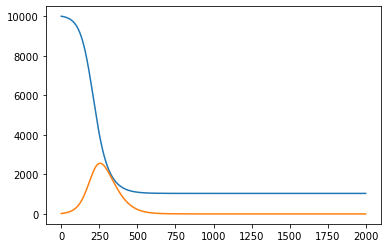

In [30]:
plt.plot(np.sum(X[:, 0:M], axis=-1))
plt.plot(np.sum(X[:, M:], axis=1))
plt.show() 